
---
## 0 · Reconnaissance

Before touching anything, look at what is there. No column selection and no type decisions
yet — those are the output of this block, not its input.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PATH = Path(".")          # folder holding flights.csv and airports.csv
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED



### 0.1 · First look

A few rows, **all columns, no type forced**. This answers what columns exist, what they are
called and what the values look like.

In [2]:
raw = pd.read_csv(PATH / "flights.csv", low_memory=False)
raw.head(10)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5,2015,1,1,4,DL,806,N3730B,SFO,MSP,25,20.0,-5.0,18.0,38.0,217.0,230.0,206.0,1589,604.0,6.0,602,610.0,8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
6,2015,1,1,4,NK,612,N635NK,LAS,MSP,25,19.0,-6.0,11.0,30.0,181.0,170.0,154.0,1299,504.0,5.0,526,509.0,-17.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
7,2015,1,1,4,US,2013,N584UW,LAX,CLT,30,44.0,14.0,13.0,57.0,273.0,249.0,228.0,2125,745.0,8.0,803,753.0,-10.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
8,2015,1,1,4,AA,1112,N3LAAA,SFO,DFW,30,19.0,-11.0,17.0,36.0,195.0,193.0,173.0,1464,529.0,3.0,545,532.0,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
9,2015,1,1,4,DL,1173,N826DN,LAS,ATL,30,33.0,3.0,12.0,45.0,221.0,203.0,186.0,1747,651.0,5.0,711,656.0,-15.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
CAUSES = ["AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY",
          "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY"]
cols = ["MONTH", "DAY", "AIRLINE", "ORIGIN_AIRPORT", "ARRIVAL_DELAY"] + CAUSES

raw.loc[raw[CAUSES].notna().any(axis=1), cols].head(10)

,MONTH,DAY,AIRLINE,ORIGIN_AIRPORT,ARRIVAL_DELAY,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
27,1,1,NK,MSP,25.0,25.0,0.0,0.0,0.0,0.0
30,1,1,NK,PHX,43.0,43.0,0.0,0.0,0.0,0.0
35,1,1,HA,LAS,15.0,0.0,0.0,15.0,0.0,0.0
50,1,1,B6,BQN,20.0,20.0,0.0,0.0,0.0,0.0
52,1,1,B6,SJU,85.0,0.0,0.0,85.0,0.0,0.0
55,1,1,B6,SJU,89.0,17.0,0.0,72.0,0.0,0.0
70,1,1,AA,DFW,102.0,0.0,0.0,0.0,0.0,102.0
73,1,1,US,PDX,60.0,0.0,0.0,60.0,0.0,0.0
74,1,1,AA,IAH,54.0,0.0,0.0,54.0,0.0,0.0
86,1,1,AA,DEN,66.0,13.0,0.0,53.0,0.0,0.0


In [4]:
pd.DataFrame({
    "inferred type": raw.dtypes.astype(str),
    "nulls": raw.isna().sum(),
    "example": raw.iloc[0]
})

,inferred type,nulls,example
YEAR,int64,0,2015
MONTH,int64,0,1
DAY,int64,0,1
DAY_OF_WEEK,int64,0,4
AIRLINE,str,0,AS
FLIGHT_NUMBER,int64,0,98
TAIL_NUMBER,str,14721,N407AS
ORIGIN_AIRPORT,str,0,ANC
DESTINATION_AIRPORT,str,0,SEA
SCHEDULED_DEPARTURE,int64,0,5



### 0.2 · Shape and memory


In [5]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              str    
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          str    
 7   ORIGIN_AIRPORT       str    
 8   DESTINATION_AIRPORT  str    
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24  CANCELLED


### 0.3 · Inventory of the 31 columns

With the structure in front of us, the columns group by what they describe. This is the step
that justifies what gets loaded and what does not.

| Group | Columns | Loaded | Reason |
|---|---|---|---|
| **Date** | YEAR · MONTH · DAY · DAY_OF_WEEK | Partly | `YEAR` is constant (2015): zero information. The other three carry the time cuts. |
| **Identifiers** | AIRLINE · FLIGHT_NUMBER · TAIL_NUMBER · ORIGIN_AIRPORT · DESTINATION_AIRPORT | Partly | Carrier and origin are the analysis keys. Flight number and tail number identify individual rows, not groups. Destination is out of scope for this report. |
| **Departure** | SCHEDULED_DEPARTURE · DEPARTURE_TIME · DEPARTURE_DELAY | Partly | The **scheduled** time defines the time band; departure delay is needed to test against arrival delay. Actual departure time is redundant given the other two. |
| **Ground and air** | TAXI_OUT · WHEELS_OFF · SCHEDULED_TIME · ELAPSED_TIME · AIR_TIME · DISTANCE · WHEELS_ON | No | They describe the mechanics of the flight, not its punctuality. Seven columns that feed no question in the case. |
| **Arrival** | TAXI_IN · SCHEDULED_ARRIVAL · ARRIVAL_TIME · ARRIVAL_DELAY | Partly | `ARRIVAL_DELAY` **is the target variable**. The other three are the ingredients it is already computed from. |
| **State** | DIVERTED · CANCELLED · CANCELLATION_REASON | Yes | They define the denominators. |
| **Causes** | the five `*_DELAY` | Yes | They carry the accountability question. |

**Result: 16 columns out of 31.**

The criterion matters more than the count: **nothing is dropped for looking unimportant — it
is dropped for feeding no question in the case.** `ARRIVAL_DELAY` already comes computed, so
the intermediate times have nothing left to contribute.

In [6]:
USE = ["MONTH", "DAY", "DAY_OF_WEEK", "AIRLINE", "ORIGIN_AIRPORT",
       "SCHEDULED_DEPARTURE", "DEPARTURE_DELAY", "ARRIVAL_DELAY",
       "DIVERTED", "CANCELLED", "CANCELLATION_REASON",
       "AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY",
       "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY", "DESTINATION_AIRPORT"]

DT = {"MONTH":"int8", "DAY":"int8", "DAY_OF_WEEK":"int8",
      "AIRLINE":"category", "ORIGIN_AIRPORT":"string",
      "SCHEDULED_DEPARTURE":"int16",
      "DEPARTURE_DELAY":"float32", "ARRIVAL_DELAY":"float32",
      "DIVERTED":"int8", "CANCELLED":"int8", "CANCELLATION_REASON":"category",
      "AIR_SYSTEM_DELAY":"float32", "SECURITY_DELAY":"float32",
      "AIRLINE_DELAY":"float32", "LATE_AIRCRAFT_DELAY":"float32",
      "WEATHER_DELAY":"float32",
      "DESTINATION_AIRPORT":"string"}

f = pd.read_csv(PATH / "flights.csv", usecols=USE, dtype=DT)

del raw            # the 1.4 GB copy is no longer needed

print(f"{f.shape[0]:,} rows x {f.shape[1]} columns")
print(f"Memory: {f.memory_usage(deep=True).sum() / 1e9:.2f} GB")

5,819,079 rows x 17 columns
Memory: 0.35 GB



---
## 1 · Missing data


In [7]:
pd.DataFrame({
    "nulls": f.isna().sum(),
    "%": (f.isna().mean() * 100).round(2)
}).sort_values("nulls", ascending=False)

,nulls,%
CANCELLATION_REASON,5729195,98.46
WEATHER_DELAY,4755640,81.72
LATE_AIRCRAFT_DELAY,4755640,81.72
AIRLINE_DELAY,4755640,81.72
SECURITY_DELAY,4755640,81.72
AIR_SYSTEM_DELAY,4755640,81.72
ARRIVAL_DELAY,105071,1.81
DEPARTURE_DELAY,86153,1.48
DAY,0,0.00
DIVERTED,0,0.00



---
## 2 · Cardinality

How many distinct values each column holds. A routine check: it drives type choices, it
predicts compression, and it exposes keys that do not behave like keys.

In [9]:
pd.DataFrame({
    "distinct": f.nunique(),
    "% of rows": (f.nunique() / len(f) * 100).round(4)
}).sort_values("distinct", ascending=False)

,distinct,% of rows
SCHEDULED_DEPARTURE,1321,0.0227
ARRIVAL_DELAY,1240,0.0213
DEPARTURE_DELAY,1217,0.0209
AIRLINE_DELAY,1067,0.0183
LATE_AIRCRAFT_DELAY,695,0.0119
WEATHER_DELAY,632,0.0109
DESTINATION_AIRPORT,629,0.0108
ORIGIN_AIRPORT,628,0.0108
AIR_SYSTEM_DELAY,570,0.0098
SECURITY_DELAY,154,0.0026



---
## 3 · Referential integrity

The check that answers the previous question: **which codes in the fact table do not exist
in the catalogue?**

In [10]:
ap = pd.read_csv(PATH / "airports.csv")
catalogue = set(ap.IATA_CODE.dropna())
in_flights = set(f.ORIGIN_AIRPORT.dropna().unique())

orphans = sorted(in_flights - catalogue)
hit = f.ORIGIN_AIRPORT.isin(orphans)

print(f"Codes with no match in the catalogue: {len(orphans)}")
print(f"Rows affected:                        {hit.sum():,}")
print(f"Share of the dataset:                 {hit.mean()*100:.2f}%")
print(f"\nFirst 15: {orphans[:15]}")

Codes with no match in the catalogue: 306
Rows affected:                        486,165
Share of the dataset:                 8.35%

First 15: ['10135', '10136', '10140', '10141', '10146', '10154', '10155', '10157', '10158', '10165', '10170', '10185', '10208', '10257', '10268']



### The finding



In [11]:
f["IS_NUMERIC"] = f.ORIGIN_AIRPORT.str.isdigit().fillna(False)

by_month = f.groupby("MONTH").agg(
    flights=("IS_NUMERIC", "size"),
    numeric=("IS_NUMERIC", "sum")
)
by_month["%"] = (by_month.numeric / by_month.flights * 100).round(1)
by_month

,flights,numeric,%
MONTH,,,
1,469968,0,0.0
2,429191,0,0.0
3,504312,0,0.0
4,485151,0,0.0
5,496993,0,0.0
6,503897,0,0.0
7,520718,0,0.0
8,510536,0,0.0
9,464946,0,0.0


In [12]:
cols = ["MONTH", "DAY", "AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]
pd.concat([f.loc[f.MONTH == 9,  cols].head(5),
           f.loc[f.MONTH == 10, cols].head(5)])

,MONTH,DAY,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT
3920766,9,1,NK,LAS,IAH
3920767,9,1,AA,SFO,CLT
3920768,9,1,DL,SFO,MSP
3920769,9,1,NK,LAS,MSP
3920770,9,1,UA,SFO,ORD
4385712,10,1,AA,14747,11298
4385713,10,1,DL,14771,13487
4385714,10,1,NK,12889,13487
4385715,10,1,AA,12892,13303
4385716,10,1,AA,14771,11057



---
## 4 · Distribution of delay



In [13]:
d = f.ARRIVAL_DELAY.dropna()

print(d.describe(percentiles=[.10, .25, .50, .75, .90, .95, .99]).round(2))


count    5714008.00
mean           4.41
std           39.05
min          -87.00
10%          -20.00
25%          -13.00
50%           -5.00
75%            8.00
90%           34.00
95%           66.00
99%          167.00
max         1971.00
Name: ARRIVAL_DELAY, dtype: float64


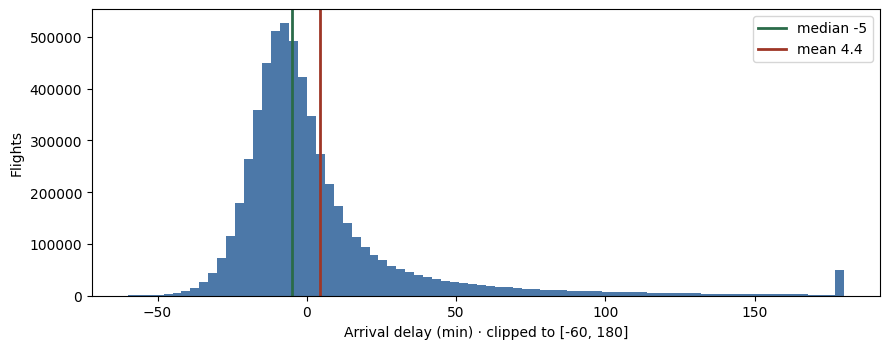

In [14]:
fig, ax = plt.subplots(figsize=(9, 3.6))

ax.hist(d.clip(-60, 180), bins=80, color="#4C78A8")
ax.axvline(d.median(), color="#2A6B49", lw=2, label=f"median {d.median():.0f}")
ax.axvline(d.mean(),   color="#9E3626", lw=2, label=f"mean {d.mean():.1f}")
ax.set_xlabel("Arrival delay (min) · clipped to [-60, 180]")
ax.set_ylabel("Flights")
ax.legend()

plt.tight_layout()
plt.show()


### The rule that governs the cause columns

Back to the question left open in block 1. With the distribution available, the threshold can
be located instead of guessed.

In [ ]:
completed = (f.CANCELLED == 0) & (f.DIVERTED == 0) & f.ARRIVAL_DELAY.notna()
comp = f[completed]
has_cause = comp[CAUSES].notna().any(axis=1)

print(f"Completed flights:         {len(comp):,}")
print(f"With a cause reported:     {has_cause.sum():,}  ({has_cause.mean()*100:.2f}%)")
print(f"Min delay WITH a cause:    {comp.loc[has_cause, 'ARRIVAL_DELAY'].min():.0f} min")
print(f"Max delay WITHOUT a cause: {comp.loc[~has_cause, 'ARRIVAL_DELAY'].max():.0f} min")

**The cut is exact: 15 minutes.** No overlap — no flight with a cause below 15, none without
a cause above 14.

It reconciles from the other side too: the 18.61% with a cause is the exact complement of the
**81.39%** arriving less than 15 minutes late. The same boundary, measured twice.

**14 CFR 234.4(j)** confirms it: *"reporting carriers are required to code delays only when the
arrival delay is 15 minutes or greater"*. Note the order — the rule came out of the data and
the regulation confirmed it, not the other way round.

→ **Decision:** the five cause columns are **not a decomposition of the universe**. They cover
the 18.6% of completed flights that are significantly late, and that is declared in the
technical note.

In [15]:
# split by cause, grouped into four accountability categories
RESPONSIBILITY = {
    "AIRLINE_DELAY":       "Controllable",
    "LATE_AIRCRAFT_DELAY": "Inherited",
    "AIR_SYSTEM_DELAY":    "Systemic",
    "WEATHER_DELAY":       "Exogenous",
    "SECURITY_DELAY":      "Exogenous",
}

minutes = f[CAUSES].sum().astype("float64")       # float64: avoids 39.799999 on screen

split = pd.DataFrame({
    "minutes": minutes.astype("int64"),
    "%": (minutes / minutes.sum() * 100).round(1),
    "responsibility": pd.Series(RESPONSIBILITY),
}).sort_values("minutes", ascending=False)
split

,minutes,%,responsibility
LATE_AIRCRAFT_DELAY,24961932,39.8,Inherited
AIRLINE_DELAY,20172956,32.2,Controllable
AIR_SYSTEM_DELAY,14335762,22.9,Systemic
WEATHER_DELAY,3100233,4.9,Exogenous
SECURITY_DELAY,80985,0.1,Exogenous



---
## 5 · Patterns

Three cuts: by month, by hour of day, and by airport.

In [16]:
monthly = f.groupby("MONTH").ARRIVAL_DELAY.agg(["size", "mean"]).round(2)
monthly.columns = ["flights", "mean_delay"]
monthly.sort_values("mean_delay", ascending=False)

,flights,mean_delay
MONTH,,
6,503897,9.60
2,429191,8.32
7,520718,6.43
12,479230,6.09
1,469968,5.81
3,504312,4.92
8,510536,4.61
5,496993,4.49
4,485151,3.16



**June is the worst month, ahead of February.** That is counter-intuitive and worth saying out
loud: winter delay is **weather-driven and concentrated in a few days**, while summer delay is
**capacity saturation, sustained across the whole month**.


In [17]:
# times arrive as HHMM integers: 545 is 05:45. The value 2400 exists and means midnight.
f["HOUR"] = (f.SCHEDULED_DEPARTURE % 2400) // 100
print("HOUR range:", f.HOUR.min(), "-", f.HOUR.max())

hourly = f.groupby("HOUR").ARRIVAL_DELAY.agg(["size", "mean"]).round(2)
hourly.columns = ["flights", "mean_delay"]
hourly

HOUR range: 0 - 23


,flights,mean_delay
HOUR,,
0,14664,0.81
1,5159,3.89
2,1414,1.82
3,778,1.73
4,531,3.70
5,118051,-3.78
6,406940,-2.61
7,393947,-1.50
8,381014,-0.19
